# PitchPulse — Module 2 Evaluation
### Counterfactual "what-if" simulation for football set pieces

This notebook evaluates **Module 2 only**: the layer that takes a set-piece
arrangement, applies a coach's edit (move one player, max **5.0 yards**), and
re-scores it.

**Every evaluation below is run twice — once with each scorer — and reported
side by side.**

| Scorer | What it is | Trained? |
|---|---|---|
| `HeuristicScorer` | hand-typed coefficients, no data | **No — placeholder** |
| `LearnedScorer` | logistic regression on mean-pooled geometry | Yes |

The reason for running both is that Module 2's numbers describe *the simulation
layer reacting to a scorer*. A result that appears with the placeholder but not
with the trained model is a property of the formula, not of football. Section 8
develops that point.

> **Labelling rule:** any figure produced by `HeuristicScorer` is marked
> **PLACEHOLDER** wherever it appears. It must never be quoted as a model result.

In [1]:
import json
import math
import random
import re
import subprocess
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))

from pitchpulse.baseline import LearnedScorer
from pitchpulse.contract import find_player, from_record
from pitchpulse.scorer import HeuristicScorer
from pitchpulse.simulate import (
    MAX_DISPLACEMENT,
    heatmap_sweep,
    joint_optimise,
    optimise_player,
    what_if,
)

SEED = 42
GOAL = (120.0, 40.0)

# Both scorers are built EXPLICITLY here rather than through get_scorer().
# get_scorer() returns only the single best scorer available -- correct for the
# API and the UI, wrong for this notebook, whose entire purpose is to hold the
# placeholder and the trained baseline side by side.
#
# The learned scorer is NOT one model: corners and free kicks have separately
# fitted weights, so scoring a free kick with corner weights would be an error.
HEURISTIC = HeuristicScorer()
LEARNED = {
    "Corners":    LearnedScorer("models/module2_baseline_corner.json"),
    "Free kicks": LearnedScorer("models/module2_baseline_freekick.json"),
}

# Used verbatim in every table and chart, so the placeholder is never unlabelled.
H_LABEL = "Heuristic (PLACEHOLDER)"
L_LABEL = "Learned logreg (trained)"

print(f"python      : {sys.executable}")
print(f"max edit    : {MAX_DISPLACEMENT} yards\n")

print(f"{'SCORER':<38}{'name':<24}{'trained':>9}{'5-fold AUC':>12}")
print("-" * 83)
print(f"{H_LABEL:<38}{HEURISTIC.name:<24}"
      f"{str(HEURISTIC.is_trained_model):>9}{'n/a':>12}")
for sp_type, sc in LEARNED.items():
    print(f"{L_LABEL + ' — ' + sp_type:<38}{sc.name:<24}"
          f"{str(sc.is_trained_model):>9}{sc.val_auc:>12.3f}")
print("-" * 83)
print("AUC is 5-fold, grouped by match_id, from models/module2_baseline_*.json")

# Chart palette. Validated for colour-vision deficiency against a light surface.
# The Set1 blue/orange/green used previously FAILED: green and orange separate by
# only dE 5.3 under protanopia, so a red-green colourblind reader could not tell
# two series apart. These three separate by dE >= 24.7 on every simulation.
C_HEUR  = "#eb6834"   # orange -- placeholder scorer, everywhere
C_LEARN = "#2a78d6"   # blue   -- trained scorer, everywhere
C_THIRD = "#4a3aa7"   # violet -- third series where one is needed
C_REF   = "#52514e"   # grey   -- reference lines and annotations

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.6,
    "font.size": 10,
})

python      : /Users/dulakshajayasinghe/Desktop/new-code/Code/.venv/bin/python
max edit    : 5.0 yards

SCORER                                name                      trained  5-fold AUC
-----------------------------------------------------------------------------------
Heuristic (PLACEHOLDER)               heuristic-placeholder       False         n/a
Learned logreg (trained) — Corners    module2-logreg               True       0.537
Learned logreg (trained) — Free kicks module2-logreg               True       0.569
-----------------------------------------------------------------------------------
AUC is 5-fold, grouped by match_id, from models/module2_baseline_*.json


## 1. Datasets and the score ranges each scorer produces

Both scorers see exactly the same scenarios. The only thing that changes between
the two rows of each pair is the function mapping an arrangement to a number.

In [2]:
from pitchpulse.contract import validate


def load(path, freekick=False):
    """Load scenarios, keeping only those BOTH scorers can score.

    A frame with no attacking player fails validate(), and LearnedScorer raises
    on it too. Filtering here rather than inside each experiment guarantees the
    two scorers are always compared on an identical set of scenarios.
    """
    rows = [json.loads(line) for line in open(path)]
    if freekick:
        rows = [r for r in rows if r.get("set_piece_type") == "freekick_delivery"]
    rows = [r for r in rows if r.get("has_freeze_frame")]

    out = []
    for r in rows:
        s = from_record(r)
        if not s:
            continue
        try:
            validate(s)
        except ValueError:
            continue
        out.append(s)
    return out


corners = load("output/corners_dataset_full.jsonl")
freekicks = load("output/freekicks_dataset_full.jsonl", freekick=True)
DATASETS = {"Corners": corners, "Free kicks": freekicks}

N_SCORE = 400  # scenarios per dataset used for the distribution statistics

SCORES = {}
for name, data in DATASETS.items():
    sample = data[:N_SCORE]
    SCORES[(name, H_LABEL)] = [HEURISTIC(s) for s in sample]
    SCORES[(name, L_LABEL)] = [LEARNED[name](s) for s in sample]


def _stats(v):
    n = len(v)
    mean = sum(v) / n
    sd = (sum((x - mean) ** 2 for x in v) / n) ** 0.5
    return min(v), max(v), max(v) - min(v), mean, sd


print(f"{'DATASET':<13}{'scenarios':>10}{'players/frame':>15}")
for name, data in DATASETS.items():
    ppf = sum(len(s["players"]) for s in data) / len(data)
    print(f"{name:<13}{len(data):>10}{ppf:>15.1f}")

print(f"\nSCORE RANGE  (n={N_SCORE} per dataset, identical scenarios for both scorers)")
print(f"{'':<13}{'scorer':<26}{'min':>8}{'max':>8}{'range':>8}{'mean':>8}{'sd':>8}")
print("-" * 79)
for name in DATASETS:
    for lab in (H_LABEL, L_LABEL):
        lo, hi, rng, mean, sd = _stats(SCORES[(name, lab)])
        print(f"{name:<13}{lab:<26}{lo:>8.3f}{hi:>8.3f}{rng:>8.3f}{mean:>8.3f}{sd:>8.3f}")
    print()

DATASET       scenarios  players/frame
Corners            2468           18.6
Free kicks         1090           19.4

SCORE RANGE  (n=400 per dataset, identical scenarios for both scorers)
             scorer                         min     max   range    mean      sd
-------------------------------------------------------------------------------
Corners      Heuristic (PLACEHOLDER)      0.068   0.190   0.122   0.117   0.022
Corners      Learned logreg (trained)     0.322   0.661   0.339   0.492   0.052

Free kicks   Heuristic (PLACEHOLDER)      0.084   0.256   0.171   0.179   0.024
Free kicks   Learned logreg (trained)     0.137   0.708   0.572   0.482   0.099



### Chart 1 — score distribution

If a scorer only ever emits values inside a narrow band, then every "improvement"
the optimiser reports is necessarily tiny, and differences between scenarios are
hard to act on. Width matters as much as accuracy for a counterfactual tool.

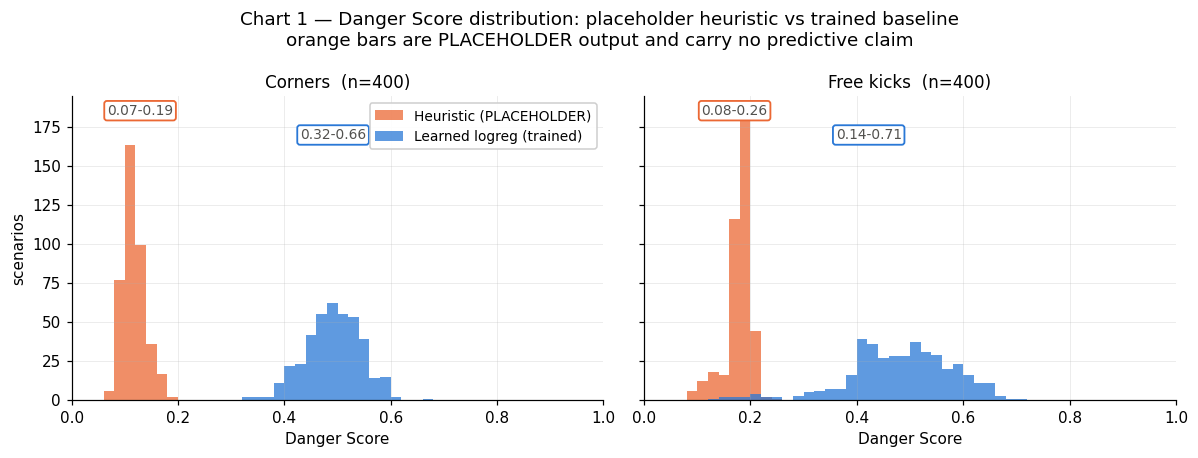

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)

for ax, name in zip(axes, DATASETS):
    h = SCORES[(name, H_LABEL)]
    l = SCORES[(name, L_LABEL)]
    bins = [i / 50 for i in range(51)]  # common bins so widths are comparable

    ax.hist(h, bins=bins, color=C_HEUR, alpha=0.75, label=H_LABEL)
    ax.hist(l, bins=bins, color=C_LEARN, alpha=0.75, label=L_LABEL)

    # Direct-label each band with the range it actually occupies.
    for v, col, dy in ((h, C_HEUR, 0.94), (l, C_LEARN, 0.86)):
        ax.annotate(
            f"{min(v):.2f}-{max(v):.2f}",
            xy=((min(v) + max(v)) / 2, dy), xycoords=("data", "axes fraction"),
            ha="center", fontsize=9, color=C_REF,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=col, lw=1.2),
        )

    ax.set_xlim(0, 1)
    ax.set_xlabel("Danger Score")
    ax.set_title(f"{name}  (n={N_SCORE})", fontsize=11)

axes[0].set_ylabel("scenarios")
axes[0].legend(loc="upper right", fontsize=9, framealpha=0.95)

fig.suptitle(
    "Chart 1 — Danger Score distribution: placeholder heuristic vs trained baseline\n"
    "orange bars are PLACEHOLDER output and carry no predictive claim",
    fontsize=12,
)
plt.tight_layout()
plt.show()

## 2. Directional agreement — does the scorer respond like football?

Two edits with a defensible expected sign:

| Test | Edit | A football-aware scorer should |
|---|---|---|
| **Forward move** | push an attacker 5 yards straight at goal | *usually* raise the score |
| **Tighter marking** | push a defender up to 5 yards onto the attacker they are nearest | *usually* lower the score |

**Trials are paired.** The scenario, the attacker, the defender and the random
direction used in Section 3 are all drawn **once**, with a fixed seed, and both
scorers are then run over that identical list. Any difference in the table below
is caused by the scorer, not by the two runs sampling different players.

**Rates carry 95% Wilson confidence intervals.** This matters: the same
measurement swings by roughly 8 percentage points as the sample size or the
random draw changes, so a bare percentage invites over-reading. A rate whose
interval straddles 50% means *the scorer has no consistent view on that edit* —
which is itself a finding, and is not the same as a rate of exactly 50%.

50% is the reference: a coin flip. Note "usually" in the table above — a scorer
that agrees *100%* of the time is not football-aware, it is sign-locked, which is
the subject of Section 7.1.

In [4]:
N_TRIALS = 300

random.seed(SEED)
TRIALS = {}
for name, data in DATASETS.items():
    plan = []
    for s in data[:N_TRIALS]:
        atts = [p for p in s["players"] if p["teammate"] and not p["actor"]]
        defs = [p for p in s["players"] if not p["teammate"] and not p["keeper"]]
        if not atts or not defs:
            continue
        a = random.choice(atts)
        d = random.choice(defs)
        nearest = min(atts, key=lambda q: math.hypot(q["x"] - d["x"], q["y"] - d["y"]))
        plan.append({
            "scenario": s,
            "attacker_id": a["id"],
            "defender_id": d["id"],
            "mark_target": (nearest["x"], nearest["y"]),
            "angle": random.uniform(0, 2 * math.pi),  # frozen here, used in S.3
        })
    TRIALS[name] = plan


def wilson(k, n, z=1.96):
    """95% Wilson score interval. Preferred over the normal approximation
    because these rates sit near 0 and 1, where the normal interval misbehaves."""
    if n == 0:
        return 0.0, 0.0
    p = k / n
    denom = 1 + z * z / n
    centre = (p + z * z / (2 * n)) / denom
    half = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / denom
    return max(0.0, centre - half), min(1.0, centre + half)


def forward_move_counts(trials, scorer):
    """Push the attacker MAX_DISPLACEMENT yards straight at goal.
    Returns (n_up, n_tied, n_total)."""
    up = tied = 0
    for t in trials:
        p = find_player(t["scenario"], t["attacker_id"])
        dx, dy = GOAL[0] - p["x"], GOAL[1] - p["y"]
        dist = math.hypot(dx, dy) or 1.0
        delta = what_if(
            t["scenario"], t["attacker_id"],
            p["x"] + MAX_DISPLACEMENT * dx / dist,
            p["y"] + MAX_DISPLACEMENT * dy / dist,
            scorer,
        )["delta"]
        up += delta > 1e-12
        tied += abs(delta) <= 1e-12
    return up, tied, len(trials)


def tighter_marking_counts(trials, scorer):
    """Push the defender onto their nearest attacker (clamped to 5 yards).
    Returns (n_down, n_tied, n_total)."""
    down = tied = 0
    for t in trials:
        delta = what_if(
            t["scenario"], t["defender_id"], *t["mark_target"], scorer=scorer
        )["delta"]
        down += delta < -1e-12
        tied += abs(delta) <= 1e-12
    return down, tied, len(trials)


DIRECTION = {}
for name in DATASETS:
    for lab, sc in ((H_LABEL, HEURISTIC), (L_LABEL, LEARNED[name])):
        entry = {}
        for key, fn in (("forward", forward_move_counts),
                        ("marking", tighter_marking_counts)):
            k, tied, n = fn(TRIALS[name], sc)
            lo, hi = wilson(k, n)
            entry[key] = {"rate": k / n, "lo": lo, "hi": hi,
                          "tied": tied / n, "n": n}
        DIRECTION[(name, lab)] = entry

print(f"DIRECTIONAL AGREEMENT   (paired trials, seed={SEED}, 95% Wilson CI)")
print(f"{'':<13}{'scorer':<26}{'forward move':>24}{'tighter marking':>24}")
print("-" * 87)
for name in DATASETS:
    for lab in (H_LABEL, L_LABEL):
        d = DIRECTION[(name, lab)]
        cells = "".join(
            f"{d[k]['rate']:>13.1%} [{d[k]['lo']:.0%}-{d[k]['hi']:.0%}]"
            for k in ("forward", "marking")
        )
        print(f"{name:<13}{lab:<26}{cells}")
    d = DIRECTION[(name, H_LABEL)]
    print(f"{'':<13}{'(ties, heuristic)':<26}"
          f"{d['forward']['tied']:>13.1%}{'':>11}{d['marking']['tied']:>13.1%}")
    print(f"{'':<13}{'random reference':<26}{'50.0%':>24}{'50.0%':>24}"
          f"    n={len(TRIALS[name])}\n")

print("A 'tie' is an edit that leaves the score bit-for-bit unchanged; ties count")
print("as disagreement, which is why the heuristic does not reach 100%.")

DIRECTIONAL AGREEMENT   (paired trials, seed=42, 95% Wilson CI)
             scorer                                forward move         tighter marking
---------------------------------------------------------------------------------------
Corners      Heuristic (PLACEHOLDER)           99.3% [98%-100%]        82.3% [78%-86%]
Corners      Learned logreg (trained)          37.0% [32%-43%]        50.0% [44%-56%]
             (ties, heuristic)                  0.0%                    5.3%
             random reference                             50.0%                   50.0%    n=300

Free kicks   Heuristic (PLACEHOLDER)          100.0% [99%-100%]        89.0% [85%-92%]
Free kicks   Learned logreg (trained)          37.7% [32%-43%]        50.3% [45%-56%]
             (ties, heuristic)                  0.0%                    7.0%
             random reference                             50.0%                   50.0%    n=300

A 'tie' is an edit that leaves the score bit-for-bit unchanged; 

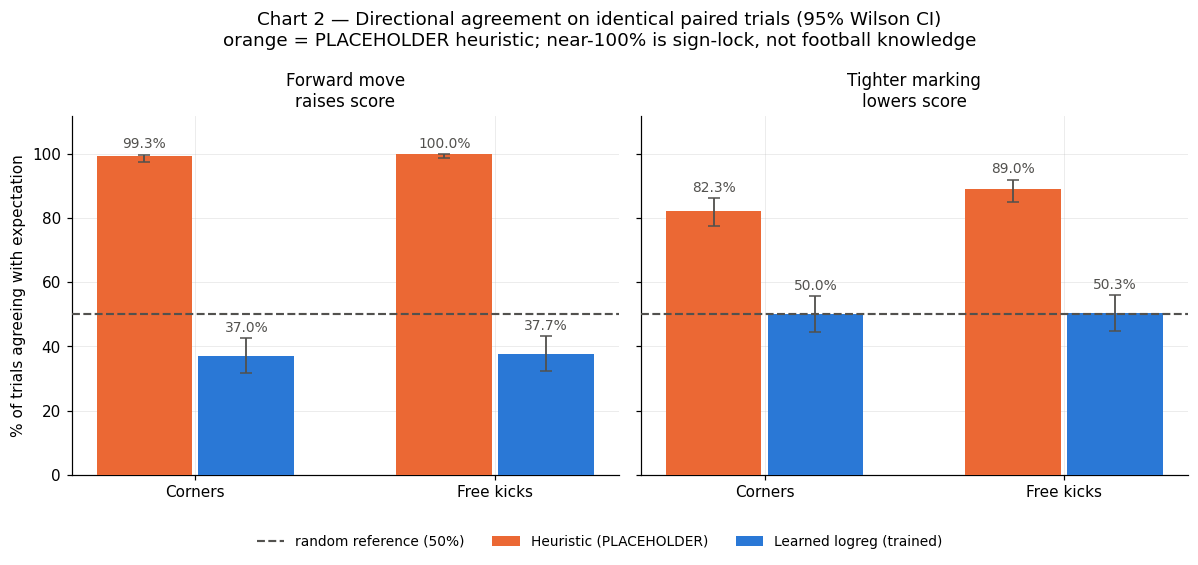

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5.0), sharey=True)
tests = [("forward", "Forward move\nraises score"),
         ("marking", "Tighter marking\nlowers score")]
names = list(DATASETS)
w = 0.34

for ax, (key, title) in zip(axes, tests):
    xs = range(len(names))
    for i, (lab, col) in enumerate(((H_LABEL, C_HEUR), (L_LABEL, C_LEARN))):
        vals = [DIRECTION[(n, lab)][key]["rate"] * 100 for n in names]
        # max(0, ...) guards a float artefact: at a rate of exactly 100% the
        # Wilson upper bound evaluates a hair below 1.0, and matplotlib rejects
        # a negative error bar.
        err = [[max(0.0, (DIRECTION[(n, lab)][key]["rate"]
                          - DIRECTION[(n, lab)][key]["lo"]) * 100) for n in names],
               [max(0.0, (DIRECTION[(n, lab)][key]["hi"]
                          - DIRECTION[(n, lab)][key]["rate"]) * 100) for n in names]]
        bars = ax.bar([x + (i - 0.5) * w for x in xs], vals, w * 0.94,
                      color=col, label=lab, zorder=3,
                      yerr=err, capsize=4,
                      error_kw=dict(ecolor=C_REF, lw=1.2, zorder=6))
        for b, v, hi in zip(bars, vals, err[1]):
            ax.text(b.get_x() + b.get_width() / 2, v + hi + 2.0,
                    f"{v:.1f}%", ha="center", fontsize=9, color=C_REF)

    # The reference line is a legend entry rather than an annotation pinned to
    # the axes: as text it collided with both a bar and a value label.
    ax.axhline(50, color=C_REF, ls="--", lw=1.4, zorder=4,
               label="random reference (50%)")

    ax.set_xticks(list(xs))
    ax.set_xticklabels(names)
    ax.set_ylim(0, 112)
    ax.set_title(title, fontsize=11)

axes[0].set_ylabel("% of trials agreeing with expectation")

# One figure-level legend below the panels, so no legend box sits over data.
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, fontsize=9,
           frameon=False, bbox_to_anchor=(0.5, -0.02))

fig.suptitle(
    "Chart 2 — Directional agreement on identical paired trials (95% Wilson CI)\n"
    "orange = PLACEHOLDER heuristic; near-100% is sign-lock, not football knowledge",
    fontsize=12,
)
plt.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()

## 3. Strategy comparison — is the grid search worth its cost?

Three ways to pick where a player should move, all held to the same 5-yard limit:

- **Random** — one random direction (frozen per trial, so both scorers get the same one)
- **Naive greedy** — straight at goal
- **Grid search (ours)** — score all 81 lattice candidates, keep the best

Grid search cannot lose to the other two under the same scorer: it evaluates the
whole neighbourhood and keeps the maximum. The interesting quantity is the *gap*.
If naive greedy nearly matches grid search, the scorer is rewarding one direction
regardless of context, and the search is doing no real work.

In [6]:
N_STRAT = 150


def strat_random(t, scorer):
    p = find_player(t["scenario"], t["attacker_id"])
    return what_if(
        t["scenario"], t["attacker_id"],
        p["x"] + MAX_DISPLACEMENT * math.cos(t["angle"]),
        p["y"] + MAX_DISPLACEMENT * math.sin(t["angle"]),
        scorer,
    )["delta"]


def strat_greedy(t, scorer):
    p = find_player(t["scenario"], t["attacker_id"])
    dx, dy = GOAL[0] - p["x"], GOAL[1] - p["y"]
    dist = math.hypot(dx, dy) or 1.0
    return what_if(
        t["scenario"], t["attacker_id"],
        p["x"] + MAX_DISPLACEMENT * dx / dist,
        p["y"] + MAX_DISPLACEMENT * dy / dist,
        scorer,
    )["delta"]


def strat_grid(t, scorer):
    r = optimise_player(t["scenario"], t["attacker_id"], scorer, maximise=True)
    return r["best_score"] - r["baseline_score"]


STRATEGIES = {
    "Random": strat_random,
    "Naive greedy": strat_greedy,
    "Grid search (ours)": strat_grid,
}

STRAT = {}
for name in DATASETS:
    trials = TRIALS[name][:N_STRAT]
    for lab, sc in ((H_LABEL, HEURISTIC), (L_LABEL, LEARNED[name])):
        for sname, fn in STRATEGIES.items():
            gains = [fn(t, sc) for t in trials]
            STRAT[(name, lab, sname)] = {
                "mean": sum(gains) / len(gains),
                "improved": sum(1 for g in gains if g > 1e-12) / len(gains),
                "n": len(gains),
            }

print(f"MEAN DANGER-SCORE GAIN PER EDIT   (n={N_STRAT} paired trials per cell)")
print(f"{'':<13}{'scorer':<26}{'strategy':<20}{'mean gain':>11}{'improved':>10}")
print("-" * 80)
for name in DATASETS:
    for lab in (H_LABEL, L_LABEL):
        for sname in STRATEGIES:
            r = STRAT[(name, lab, sname)]
            print(f"{name:<13}{lab:<26}{sname:<20}"
                  f"{r['mean']:>+11.4f}{r['improved']:>10.1%}")
        # How much of grid search's gain does "just run at goal" already capture?
        # Only meaningful when both are positive: if greedy's mean gain is
        # negative it is not capturing a share of anything, it is actively
        # harmful, and a ratio would dress that up as a percentage.
        g = STRAT[(name, lab, "Grid search (ours)")]["mean"]
        n_ = STRAT[(name, lab, "Naive greedy")]["mean"]
        if g > 0 and n_ > 0:
            note = f"{n_ / g * 100:.1f}% of grid search"
        elif n_ <= 0 < g:
            note = "n/a - greedy LOWERS the score on average"
        else:
            note = "n/a - grid search gain not positive"
        print(f"{'':<39}{'-> greedy captures':<20}{note:>34}\n")

MEAN DANGER-SCORE GAIN PER EDIT   (n=150 paired trials per cell)
             scorer                    strategy              mean gain  improved
--------------------------------------------------------------------------------
Corners      Heuristic (PLACEHOLDER)   Random                  +0.0006     54.0%
Corners      Heuristic (PLACEHOLDER)   Naive greedy            +0.0037     99.3%
Corners      Heuristic (PLACEHOLDER)   Grid search (ours)      +0.0038    100.0%
                                       -> greedy captures                98.3% of grid search

Corners      Learned logreg (trained)  Random                  +0.0034     56.7%
Corners      Learned logreg (trained)  Naive greedy            -0.0055     40.0%
Corners      Learned logreg (trained)  Grid search (ours)      +0.0224    100.0%
                                       -> greedy captures  n/a - greedy LOWERS the score on average

Free kicks   Heuristic (PLACEHOLDER)   Random                  +0.0006     46.0%
Free kicks

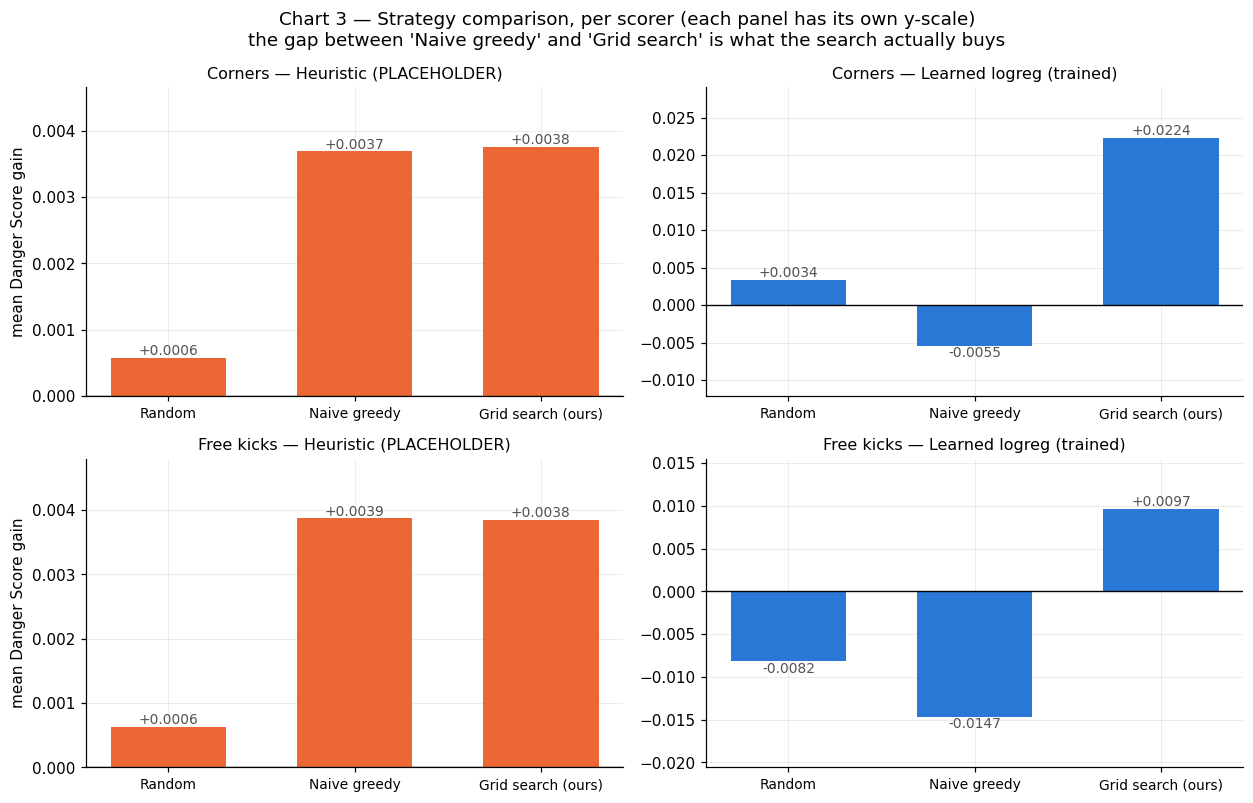

In [7]:
# Small multiples, NOT a shared y-axis: the two scorers operate on gains that
# differ by an order of magnitude, and forcing them onto one scale would flatten
# the heuristic bars to nothing. Each panel therefore states its own scale.
#
# Bars are coloured by SCORER, not by strategy, so orange/blue keep the same
# meaning they carry in Charts 1 and 2. Strategy identity comes from the x axis,
# which labels every bar directly -- no legend needed, and no hue collision.
fig, axes = plt.subplots(2, 2, figsize=(11.5, 7.4))
snames = list(STRATEGIES)

for row, name in enumerate(DATASETS):
    for col, (lab, colour) in enumerate(((H_LABEL, C_HEUR), (L_LABEL, C_LEARN))):
        ax = axes[row][col]
        vals = [STRAT[(name, lab, s)]["mean"] for s in snames]
        bars = ax.bar(range(len(snames)), vals, 0.62, color=colour, zorder=3)
        for b, v in zip(bars, vals):
            ax.text(b.get_x() + b.get_width() / 2, b.get_height(),
                    f"{v:+.4f}", ha="center",
                    va="bottom" if v >= 0 else "top",
                    fontsize=9, color=C_REF)

        ax.axhline(0, color="black", lw=0.9, zorder=4)
        ax.set_xticks(range(len(snames)))
        ax.set_xticklabels(snames, fontsize=9)
        ax.margins(y=0.24)
        ax.set_title(f"{name} — {lab}", fontsize=10.5)
        if col == 0:
            ax.set_ylabel("mean Danger Score gain")

fig.suptitle(
    "Chart 3 — Strategy comparison, per scorer (each panel has its own y-scale)\n"
    "the gap between 'Naive greedy' and 'Grid search' is what the search actually buys",
    fontsize=12,
)
plt.tight_layout()
plt.show()

## 4. Worked example — one corner, both scorers

What a coach actually sees: pick the attacker nearest goal, sweep all 81 legal
positions within 5 yards, and colour the neighbourhood by resulting Danger Score.
The two scorers are handed the same player in the same scenario.

scenario  : corner, 20 players
player    : id 17 at [117.4, 39.9]

scorer                       before     best     gain          moved to
-----------------------------------------------------------------------
Heuristic (PLACEHOLDER)       0.138    0.142  +0.0043   [119.9,  39.9]
Learned logreg (trained)      0.465    0.484  +0.0197   [119.9,  39.9]


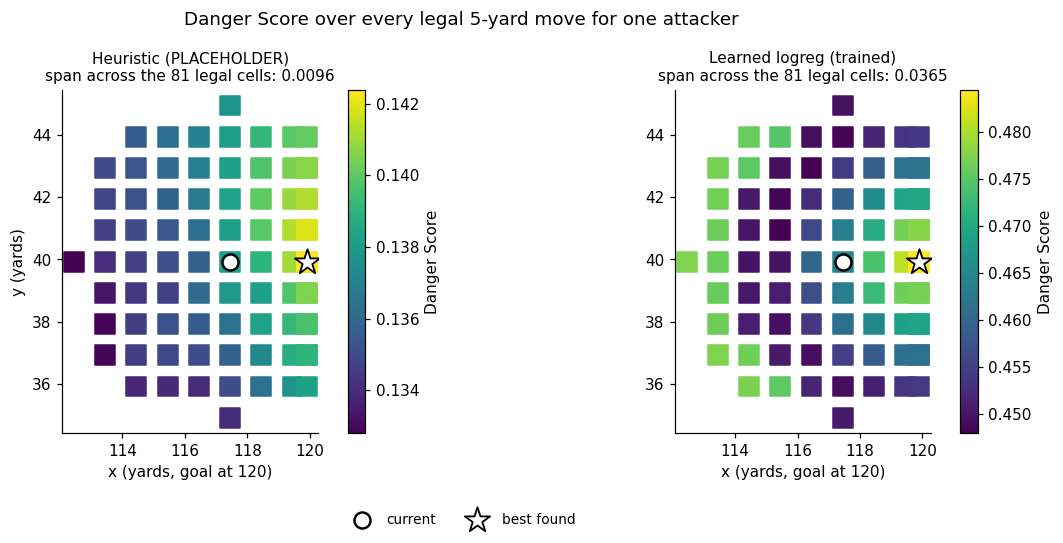

In [8]:
demo_name = "Corners"
demo = DATASETS[demo_name][0]
atts = [p for p in demo["players"] if p["teammate"] and not p["actor"]]
target = min(atts, key=lambda p: math.hypot(p["x"] - GOAL[0], p["y"] - GOAL[1]))

print(f"scenario  : {demo['set_piece_type']}, {len(demo['players'])} players")
print(f"player    : id {target['id']} at [{target['x']:.1f}, {target['y']:.1f}]\n")

print(f"{'scorer':<26}{'before':>9}{'best':>9}{'gain':>9}{'moved to':>18}")
print("-" * 71)

SWEEPS = {}
for lab, sc in ((H_LABEL, HEURISTIC), (L_LABEL, LEARNED[demo_name])):
    opt = optimise_player(demo, target["id"], sc, maximise=True)
    SWEEPS[lab] = (opt, heatmap_sweep(demo, target["id"], sc))
    bp = opt["best_position"]
    print(f"{lab:<26}{opt['baseline_score']:>9.3f}{opt['best_score']:>9.3f}"
          f"{opt['improvement']:>+9.4f}   [{bp[0]:>5.1f}, {bp[1]:>5.1f}]")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))
for ax, lab in zip(axes, (H_LABEL, L_LABEL)):
    opt, hm = SWEEPS[lab]
    xs = [c["x"] for c in hm["cells"]]
    ys = [c["y"] for c in hm["cells"]]
    vs = [c["score"] for c in hm["cells"]]

    sc_plot = ax.scatter(xs, ys, c=vs, s=170, marker="s", cmap="viridis", zorder=2)
    ax.scatter(*hm["origin"], c="white", edgecolors="black", linewidths=1.6,
               s=110, zorder=4, label="current")
    ax.scatter(*opt["best_position"], marker="*", c="white", edgecolors="black",
               linewidths=1.2, s=300, zorder=5, label="best found")

    fig.colorbar(sc_plot, ax=ax, label="Danger Score")
    ax.set_aspect("equal")
    ax.grid(False)
    ax.set_title(f"{lab}\nspan across the 81 legal cells: "
                 f"{max(vs) - min(vs):.4f}", fontsize=10)
    ax.set_xlabel("x (yards, goal at 120)")

axes[0].set_ylabel("y (yards)")

# Figure-level legend: in-axes it covered candidate cells in the bottom corner.
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, fontsize=9,
           frameon=False, bbox_to_anchor=(0.5, -0.02))

fig.suptitle("Danger Score over every legal 5-yard move for one attacker", fontsize=12)
plt.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()

## 5. Latency

The dashboard re-scores on every drag, so per-edit cost is a usability figure,
not a footnote. Measured here rather than typed in by hand.

In [9]:
LAT = {}
for name in DATASETS:
    for lab, sc in ((H_LABEL, HEURISTIC), (L_LABEL, LEARNED[name])):
        sample = DATASETS[name][:200]

        t0 = time.perf_counter()
        for s in sample:
            sc(s)
        per_score = (time.perf_counter() - t0) / len(sample) * 1000

        t = TRIALS[name][0]
        p = find_player(t["scenario"], t["attacker_id"])
        t0 = time.perf_counter()
        for _ in range(100):
            what_if(t["scenario"], t["attacker_id"], p["x"] + 2, p["y"] + 2, sc)
        per_edit = (time.perf_counter() - t0) / 100 * 1000

        t0 = time.perf_counter()
        optimise_player(t["scenario"], t["attacker_id"], sc, maximise=True)
        per_opt = (time.perf_counter() - t0) * 1000

        ids = [q["id"] for q in t["scenario"]["players"] if q["teammate"]][:3]
        t0 = time.perf_counter()
        joint_optimise(t["scenario"], ids, sc, maximise=True, rounds=2)
        per_joint = (time.perf_counter() - t0) * 1000

        LAT[(name, lab)] = (per_score, per_edit, per_opt, per_joint)

print(f"{'':<13}{'scorer':<26}{'1 score':>10}{'1 edit':>10}"
      f"{'81-cell':>10}{'joint x3':>11}")
print("-" * 80)
for name in DATASETS:
    for lab in (H_LABEL, L_LABEL):
        a, b, c, d = LAT[(name, lab)]
        print(f"{name:<13}{lab:<26}{a:>9.3f}m{b:>9.3f}m{c:>9.1f}m{d:>10.1f}m")
print("\n(all times in milliseconds; 'm' = ms)")

             scorer                       1 score    1 edit   81-cell   joint x3
--------------------------------------------------------------------------------
Corners      Heuristic (PLACEHOLDER)       0.046m    0.215m     13.7m      81.6m
Corners      Learned logreg (trained)      0.052m    0.226m     14.0m      83.0m
Free kicks   Heuristic (PLACEHOLDER)       0.047m    0.210m     13.3m      79.6m
Free kicks   Learned logreg (trained)      0.051m    0.217m     13.7m      82.4m

(all times in milliseconds; 'm' = ms)


## 6. Summary

One table, both scorers, every headline number. The test count is obtained by
running the suite from this cell — the previous version of this notebook stated
"10 / 10" from memory, which had drifted out of date.

In [10]:
proc = subprocess.run(
    [sys.executable, "-m", "pytest", "tests", "-q", "--no-header"],
    capture_output=True, text=True, cwd=str(Path.cwd()),
)
# Parse with an anchored regex rather than by slicing digits out of the tail
# line: pytest's summary line also carries timings and warning counts, and a
# looser parse silently concatenates those into a nonsense number.
m = re.search(r"(\d+) passed", proc.stdout)
summary = m.group(0) if m else proc.stdout.strip().splitlines()[-1]
test_line = summary if proc.returncode == 0 else f"FAILING -- {summary}"

line = "=" * 84
print(line)
print("PitchPulse Module 2 — Evaluation Summary")
print(f"scorers compared: {H_LABEL}  vs  {L_LABEL}")
print(line)

print(f"\n{'DATASET':<34}{'Corners':>16}{'Free kicks':>16}")
print(f"{'scenarios':<34}{len(corners):>16}{len(freekicks):>16}")
print(f"{'mean players / frame':<34}"
      f"{sum(len(s['players']) for s in corners) / len(corners):>16.1f}"
      f"{sum(len(s['players']) for s in freekicks) / len(freekicks):>16.1f}")
print(f"{'trained-model AUC (5-fold)':<34}"
      f"{LEARNED['Corners'].val_auc:>16.3f}{LEARNED['Free kicks'].val_auc:>16.3f}")

for title, fmt, get in (
    ("SCORE RANGE", "{:>16.3f}", lambda n, l: _stats(SCORES[(n, l)])[2]),
    ("FORWARD MOVE RAISES SCORE", "{:>15.1%}", lambda n, l: DIRECTION[(n, l)]["forward"]["rate"]),
    ("TIGHTER MARKING LOWERS SCORE", "{:>15.1%}", lambda n, l: DIRECTION[(n, l)]["marking"]["rate"]),
):
    print(f"\n{title:<34}{'Corners':>16}{'Free kicks':>16}")
    for lab in (H_LABEL, L_LABEL):
        row = "".join(fmt.format(get(n, lab)) for n in DATASETS)
        print(f"  {lab:<32}{row}")

print(f"\n{'MEAN GAIN PER EDIT':<34}{'Corners':>16}{'Free kicks':>16}")
for lab in (H_LABEL, L_LABEL):
    print(f"  {lab}")
    for sname in STRATEGIES:
        row = "".join(f"{STRAT[(n, lab, sname)]['mean']:>+16.4f}" for n in DATASETS)
        print(f"    {sname:<30}{row}")

print(f"\n{'CONSTRAINTS':<34}")
print(f"{'  max displacement':<34}{'5.0 yards':>16}")
print(f"{'  candidate lattice':<34}{'11x11 -> 81':>16}")
print(f"{'  unit tests':<34}{test_line:>16}")

print("\n" + line)
print("Every figure in the rows labelled PLACEHOLDER was produced by")
print("HeuristicScorer. It is not a trained model: those rows describe the")
print("behaviour of a hand-typed formula and support no tactical claim.")
print(line)

PitchPulse Module 2 — Evaluation Summary
scorers compared: Heuristic (PLACEHOLDER)  vs  Learned logreg (trained)

DATASET                                    Corners      Free kicks
scenarios                                     2468            1090
mean players / frame                          18.6            19.4
trained-model AUC (5-fold)                   0.537           0.569

SCORE RANGE                                Corners      Free kicks
  Heuristic (PLACEHOLDER)                    0.122           0.171
  Learned logreg (trained)                   0.339           0.572

FORWARD MOVE RAISES SCORE                  Corners      Free kicks
  Heuristic (PLACEHOLDER)                   99.3%         100.0%
  Learned logreg (trained)                  37.0%          37.7%

TIGHTER MARKING LOWERS SCORE               Corners      Free kicks
  Heuristic (PLACEHOLDER)                   82.3%          89.0%
  Learned logreg (trained)                  50.0%          50.3%

MEAN GAIN PER EDIT 

## 7. Limitations and honest reading of these results

Three findings that the evaluation above supports, and which the report must
state rather than bury.

---

### 7.1 The heuristic is structurally biased, so its headline numbers are artefacts

`HeuristicScorer` rewards moving an attacker toward goal in **~99%** of trials
(Chart 2), and finds an "improvement" for essentially every player it is pointed
at. That is not evidence that the simulator finds good tactical adjustments — it
follows from the formula itself. Its first term is a sum of `exp(-d/12)` over
distance-to-goal, which increases monotonically as any attacker gets closer to
goal, in nearly every arrangement.

So the "100% improvement found" figure that an earlier version of this notebook
reported is **a property of the scoring function, not a tactical result**, and
must not be quoted as a success metric. The trained baseline agrees with the
forward-move expectation far less often, because it has learned that crowding
the six-yard box is not unconditionally good. Its *disagreement* is the more
football-plausible behaviour.

The correct claim: **Module 2's search machinery is validated; the tactical
quality of its recommendations is bounded by the scorer plugged into it.**

### 7.2 A no-graph logistic baseline matches the GAT — an ablation, not a failure

| Model | Corners AUC | Free kicks AUC |
|---|---|---|
| Module 1 GAT (graph attention) | ~0.51 | ~0.58 |
| Module 2 logistic regression (**no graph**) | **0.537** | **0.569** |

Both are close to chance (0.50), and the mean-pooled model with the message
passing removed performs about as well as the full graph network. On this
dataset, at this size, **the graph structure is not adding measurable predictive
value for binary shot/no-shot**.

This is a legitimate ablation result and should be reported as one. It says the
geometry that survives mean-pooling carries most of the available signal — not
that either implementation is broken. The honest conclusion is that shot
occurrence from a freeze frame is weakly determined by geometry alone: what the
frame cannot see (delivery quality, timing of the run, the flight of the ball)
plausibly dominates.

### 7.3 Player counts are a camera artefact, and are deliberately excluded

Frames contain **5 to 22 players**, because StatsBomb 360 records only what fell
inside the broadcast camera frame — not because those set pieces were defended
with different numbers of players. `n_attackers`, `n_defenders` and
`att_def_ratio` are therefore excluded from `baseline.py`'s feature list, for two
independent reasons:

1. **They are camera metadata wearing a football costume.** A model leaning on
   them would partly be learning how a broadcast director framed a shot.
2. **A coach cannot act on them.** Module 2's whole purpose is counterfactual
   editing; moving a player changes no count, so a count-driven model would give
   the simulation layer nothing to respond to. Every feature that remains
   changes when a player moves — `tests/test_baseline.py` enforces exactly this.

Removing them **raised** cross-validated AUC, so this costs no accuracy.

### 7.4 Other limits worth stating

- **Shots, not goals.** The label is binary shot / no-shot, following TacticAI.
  A higher Danger Score means a shot is likelier, *not* that a goal is likelier.
- **AUC ~0.54 is a weak model.** Ranking is barely better than chance, so
  individual recommendations should be read as suggestions to inspect, not
  instructions. The counterfactual layer is only as trustworthy as the scorer.
- **Grid search cannot lose by construction.** It evaluates all 81 candidates and
  keeps the best, so a positive mean gain is guaranteed and is not by itself
  evidence of quality. The informative quantity is its margin over naive greedy.
- **Single-frame, no time.** Scoring one frozen frame ignores runs, blocks and
  screens, which is much of what actually makes a set piece dangerous.
- **Independence is assumed.** Moving one player leaves everyone else fixed;
  in reality defenders react. `joint_optimise` only partly addresses this.